
<h1>PROJECT AKHIR DATA MINING</h1>
<h2>Metode Klasifikasi — Prediksi Status Pinjaman Pelanggan</h2>

Notebook ini dibuat untuk tugas UAS Data Mining dengan menggunakan framework **CRISP-DM**.

<b>Dataset:</b> data.csv  
<b>Jumlah data:</b> 50.000 baris dan 20 kolom  
<b>Target klasifikasi:</b> status_pinjaman  
<b>Metode:</b> Classification / Klasifikasi  
<b>Algoritma yang dibandingkan:</b> Decision Tree, Random Forest, Logistic Regression, dan K-Nearest Neighbor  

<hr>

<h3>FASE 1 — Business Understanding</h3>

<b>Latar Belakang:</b>  
Dataset ini berisi data pelanggan dan informasi finansial yang berkaitan dengan pinjaman, seperti usia, status pekerjaan, lama bekerja, pendapatan tahunan, skor kredit, jumlah pinjaman, suku bunga, rasio hutang, rasio pinjaman, serta status pinjaman. Dalam dunia keuangan, proses penilaian pinjaman sangat penting untuk membantu perusahaan menentukan kelayakan atau status pinjaman pelanggan secara lebih cepat dan objektif.

<b>Tujuan Project:</b>  
Membangun model klasifikasi untuk memprediksi <code>status_pinjaman</code> berdasarkan karakteristik pelanggan dan informasi keuangan yang tersedia pada dataset.

<b>Manfaat Analisis:</b>  
1. Membantu proses analisis status pinjaman pelanggan.  
2. Memberikan gambaran faktor-faktor yang berpengaruh terhadap status pinjaman.  
3. Membantu pengambilan keputusan berbasis data.  
4. Mengurangi proses analisis manual yang membutuhkan waktu lebih lama.

<b>Pertanyaan Analitik:</b>  
1. Apakah status pinjaman pelanggan dapat diprediksi berdasarkan data keuangan dan profil pelanggan?  
2. Algoritma klasifikasi mana yang memberikan performa terbaik?  
3. Apakah model mampu mencapai kriteria sukses minimal 80%?  
4. Fitur apa saja yang paling berpengaruh dalam proses klasifikasi?

<b>Kriteria Sukses:</b>  
- Accuracy minimal 80%.  
- Nilai precision, recall, dan F1-score digunakan sebagai evaluasi tambahan.  
- Model terbaik akan dipilih berdasarkan performa evaluasi pada data testing.


# Penjelasan Cell

## Import Library

### Tujuan

Mengimpor seluruh library yang dibutuhkan untuk pengolahan data, visualisasi, preprocessing, pemodelan, dan evaluasi klasifikasi status pinjaman.

### Penjelasan Kode

* `os` : mengelola file dan lokasi dataset.
* `warnings` : menyembunyikan pesan warning.
* `numpy` : melakukan perhitungan numerik.
* `pandas` : membaca dan mengolah dataset.
* `matplotlib` dan `seaborn` : membuat visualisasi data.
* `train_test_split` dan `cross_val_score` : membagi data serta melakukan validasi model.
* `OneHotEncoder` dan `StandardScaler` : preprocessing data.
* `SimpleImputer` : menangani missing value.
* `Pipeline` dan `ColumnTransformer` : mengotomatisasi preprocessing.
* `Decision Tree`, `Random Forest`, `Logistic Regression`, dan `KNN` : algoritma klasifikasi yang digunakan untuk memprediksi status pinjaman.

### Kesimpulan

Cell ini menyiapkan seluruh library yang diperlukan agar proses analisis data mining dapat berjalan dengan baik dari tahap pengolahan data hingga evaluasi model.


In [1]:

# ==============================================================
# 1. IMPORT LIBRARY
# ==============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')
np.random.seed(42)

print('Library berhasil diimport!')


Library berhasil diimport!


# Penjelasan Cell

## Load Dataset

### Tujuan
Membaca dataset pinjaman pelanggan ke dalam DataFrame Pandas dan memastikan data berhasil dimuat untuk proses analisis.

### Penjelasan Kode
- `DATA_PATH = 'data.csv'` : menentukan lokasi file dataset.
- `pd.read_csv(DATA_PATH)` : membaca dataset berformat CSV ke dalam DataFrame.
- `df.shape` : menampilkan jumlah baris dan kolom pada dataset.
- `df.head()` : menampilkan 5 data pertama untuk melihat isi dataset.
- `df.info()` : menampilkan informasi struktur data, seperti nama kolom, tipe data, dan jumlah data non-null.

Dataset berisi informasi pelanggan seperti usia, pendapatan tahunan, skor kredit, pekerjaan, tujuan pinjaman, dan status pinjaman.

### Kesimpulan
Cell ini digunakan untuk memuat dan memeriksa dataset sehingga data siap digunakan pada tahap analisis dan pemodelan selanjutnya.

In [2]:

# ==============================================================
# 2. LOAD DATASET
# ==============================================================

print('=' * 70)
print('  LOAD DATASET')
print('=' * 70)

DATA_PATH = 'data.csv'

# Fallback path khusus jika notebook dijalankan di lingkungan ChatGPT/sandbox
if not os.path.exists(DATA_PATH) and os.path.exists('/mnt/data/data.csv'):
    DATA_PATH = '/mnt/data/data.csv'

df = pd.read_csv(DATA_PATH)

print(f'File dataset yang digunakan : {DATA_PATH}')
print(f'Jumlah baris dan kolom      : {df.shape}')
print('\n5 Data Teratas:')
display(df.head())

print('\nInformasi Dataset:')
df.info()


  LOAD DATASET
File dataset yang digunakan : data.csv
Jumlah baris dan kolom      : (50000, 20)

5 Data Teratas:


,id_pelanggan,usia,status_pekerjaan,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,tipe_produk,tujuan_pinjaman,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
0,CUST100000,40.0,Bekerja,17.2,25579,692,5.3,895,10820,0,0,0,Kartu Kredit,Bisnis,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33.0,Bekerja,7.3,43087,627,3.5,169,16550,0,1,0,Pinjaman Pribadi,Renovasi Rumah,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42.0,Mahasiswa,1.1,20840,689,8.4,17,7852,0,0,0,Kartu Kredit,Konsolidasi Hutang,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53.0,Mahasiswa,0.5,29147,692,9.8,1480,11603,0,1,0,Kartu Kredit,Bisnis,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32.0,Bekerja,12.5,63657,630,7.2,209,12424,0,0,0,Pinjaman Pribadi,Pendidikan,99600,13.92,0.195,1.565,0.522,1



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id_pelanggan                          50000 non-null  object 
 1   usia                                  49853 non-null  float64
 2   status_pekerjaan                      49847 non-null  object 
 3   lama_bekerja_tahun                    50000 non-null  float64
 4   pendapatan_tahunan                    50000 non-null  int64  
 5   skor_kredit                           50000 non-null  int64  
 6   lama_riwayat_kredit_tahun             50000 non-null  float64
 7   aset_tabungan                         50000 non-null  int64  
 8   hutang_saat_ini                       50000 non-null  int64  
 9   gagal_bayar_tercatat                  50000 non-null  int64  
 10  tunggakan_2thn_terakhir               50000 non-null  int64  



<h3>FASE 2 — Data Understanding</h3>

Pada tahap ini dilakukan pemahaman awal terhadap dataset, meliputi jumlah data, tipe data, statistik deskriptif, missing values, data duplikat, distribusi target, dan visualisasi awal. Dataset memiliki target klasifikasi yaitu <code>status_pinjaman</code> yang bernilai 0 dan 1.

<b>Catatan:</b> Karena dataset tidak menyertakan kamus data secara terpisah, arti label 0 dan 1 perlu disesuaikan kembali dengan sumber dataset asli. Pada notebook ini, label tersebut digunakan sebagai kelas klasifikasi untuk memprediksi status pinjaman pelanggan.


# Penjelasan Cell

## Data Understanding

### Tujuan
Memahami struktur dan karakteristik dataset sebelum dilakukan proses preprocessing dan pemodelan.

### Penjelasan Kode
- `df.columns` : menampilkan seluruh nama kolom atau atribut yang terdapat pada dataset.
- `df.nunique()` : menampilkan jumlah nilai unik pada setiap kolom.
- `df.isnull().sum()` : menampilkan jumlah data kosong (missing value) pada setiap kolom.
- `df.describe()` : menampilkan statistik deskriptif untuk data numerik, seperti rata-rata, nilai minimum, nilai maksimum, dan standar deviasi.
- `df.describe(include='object')` : menampilkan statistik deskriptif untuk data kategorikal, seperti jumlah kategori dan nilai yang paling sering muncul.

Melalui analisis ini dapat diketahui informasi seperti rata-rata usia pelanggan, rata-rata pendapatan tahunan, rata-rata skor kredit, serta kategori yang paling dominan seperti pekerjaan dan tujuan pinjaman.

### Kesimpulan
Cell ini digunakan untuk memahami kondisi awal dataset dan mengidentifikasi permasalahan data yang perlu ditangani sebelum proses pemodelan dilakukan.

In [3]:

# ==============================================================
# FASE 2 - DATA UNDERSTANDING
# ==============================================================

print('=' * 70)
print('  FASE 2: DATA UNDERSTANDING')
print('=' * 70)

print('Nama Kolom Dataset:')
for i, col in enumerate(df.columns, start=1):
    print(f'{i}. {col}')

print('\nJumlah Baris dan Kolom:')
print(df.shape)

print('\nTipe Data Setiap Kolom:')
display(pd.DataFrame({
    'Kolom': df.columns,
    'Tipe Data': df.dtypes.astype(str),
    'Jumlah Unique': df.nunique().values,
    'Missing Values': df.isnull().sum().values
}))

print('\nStatistik Deskriptif Data Numerik:')
display(df.describe())

print('\nStatistik Deskriptif Data Kategorikal:')
display(df.describe(include='object'))


  FASE 2: DATA UNDERSTANDING
Nama Kolom Dataset:
1. id_pelanggan
2. usia
3. status_pekerjaan
4. lama_bekerja_tahun
5. pendapatan_tahunan
6. skor_kredit
7. lama_riwayat_kredit_tahun
8. aset_tabungan
9. hutang_saat_ini
10. gagal_bayar_tercatat
11. tunggakan_2thn_terakhir
12. catatan_negatif
13. tipe_produk
14. tujuan_pinjaman
15. jumlah_pinjaman
16. suku_bunga
17. rasio_hutang_terhadap_pendapatan
18. rasio_pinjaman_terhadap_pendapatan
19. rasio_pembayaran_terhadap_pendapatan
20. status_pinjaman

Jumlah Baris dan Kolom:
(50000, 20)

Tipe Data Setiap Kolom:


,Kolom,Tipe Data,Jumlah Unique,Missing Values
id_pelanggan,id_pelanggan,object,50000,0
usia,usia,float64,53,147
status_pekerjaan,status_pekerjaan,object,3,153
lama_bekerja_tahun,lama_bekerja_tahun,float64,395,0
pendapatan_tahunan,pendapatan_tahunan,int64,35770,0
skor_kredit,skor_kredit,int64,432,0
lama_riwayat_kredit_tahun,lama_riwayat_kredit_tahun,float64,301,0
aset_tabungan,aset_tabungan,int64,10382,0
hutang_saat_ini,hutang_saat_ini,int64,25350,0
gagal_bayar_tercatat,gagal_bayar_tercatat,int64,2,0



Statistik Deskriptif Data Numerik:


,usia,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
count,49853.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.957034,7.454868,50062.892040,643.614820,8.168274,3595.619400,14290.442220,0.053480,0.55464,0.147640,33041.874000,15.498591,0.285724,0.701999,0.233995,0.550460
std,11.115165,7.612097,32630.501014,64.731518,7.207552,13232.399398,13243.757493,0.224991,0.84505,0.412996,26116.185102,4.067942,0.159787,0.465788,0.155268,0.497452
min,18.000000,0.000000,15000.000000,348.000000,0.000000,0.000000,60.000000,0.000000,0.00000,0.000000,500.000000,6.000000,0.002000,0.008000,0.003000,0.000000
25%,26.000000,1.300000,27280.500000,600.000000,2.000000,130.000000,5581.000000,0.000000,0.00000,0.000000,12300.000000,12.180000,0.161000,0.333000,0.111000,0.000000
50%,35.000000,4.900000,41607.500000,643.000000,6.100000,568.000000,10385.000000,0.000000,0.00000,0.000000,26100.000000,15.440000,0.265000,0.622000,0.207000,1.000000
75%,43.000000,11.400000,62723.250000,687.000000,12.600000,2271.000000,18449.250000,0.000000,1.00000,0.000000,48500.000000,18.870000,0.389000,1.010250,0.337000,1.000000
max,70.000000,39.900000,250000.000000,850.000000,30.000000,300000.000000,163344.000000,1.000000,9.00000,4.000000,100000.000000,23.000000,0.800000,2.001000,0.667000,1.000000



Statistik Deskriptif Data Kategorikal:


,id_pelanggan,status_pekerjaan,tipe_produk,tujuan_pinjaman
count,50000,49847,50000,50000
unique,50000,3,3,6
top,CUST100000,Bekerja,Kartu Kredit,Pribadi
freq,1,34853,22455,12429


# Penjelasan Cell

## Eksplorasi Target

### Tujuan
Menganalisis variabel target yaitu `status_pinjaman` untuk mengetahui distribusi kelas yang akan diprediksi oleh model klasifikasi.

### Penjelasan Kode
- `target_col = 'status_pinjaman'` : menentukan kolom target yang akan diprediksi.
- `value_counts()` : menghitung jumlah data pada setiap kelas status pinjaman.
- `value_counts(normalize=True)` : menghitung persentase masing-masing kelas terhadap total data.
- `sns.countplot()` : menampilkan visualisasi distribusi target dalam bentuk grafik batang.

Melalui analisis ini dapat diketahui jumlah dan persentase pinjaman yang disetujui maupun tidak disetujui serta melihat apakah distribusi data target seimbang atau tidak.

### Kesimpulan
Cell ini digunakan untuk memahami karakteristik variabel target sebelum pemodelan sehingga dapat diketahui kondisi distribusi kelas dan potensi masalah class imbalance pada dataset.

  DISTRIBUSI TARGET KLASIFIKASI
Kolom target yang digunakan: status_pinjaman


,Kelas Target,Jumlah Data,Persentase (%)
0,0,22477,44.95
1,1,27523,55.05


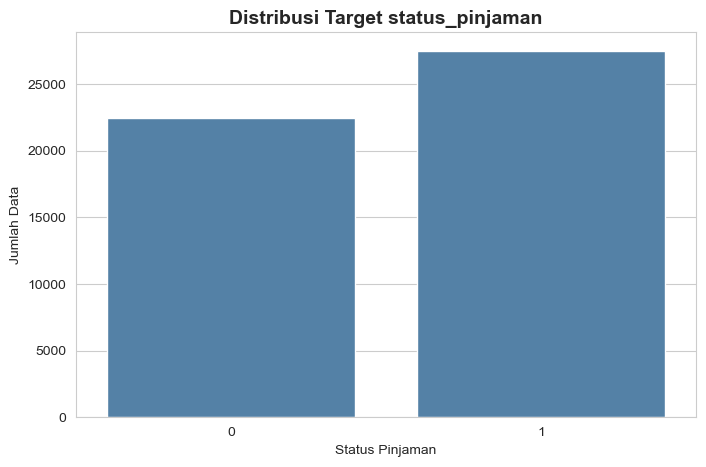

In [4]:

# ==============================================================
# EKSPLORASI TARGET KLASIFIKASI
# ==============================================================

target_col = 'status_pinjaman'

print('=' * 70)
print('  DISTRIBUSI TARGET KLASIFIKASI')
print('=' * 70)

print(f'Kolom target yang digunakan: {target_col}')

target_count = df[target_col].value_counts().sort_index()
target_percent = df[target_col].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    'Kelas Target': target_count.index,
    'Jumlah Data': target_count.values,
    'Persentase (%)': target_percent.round(2).values
}))

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target_col, color='steelblue')
plt.title('Distribusi Target status_pinjaman', fontsize=14, fontweight='bold')
plt.xlabel('Status Pinjaman')
plt.ylabel('Jumlah Data')
plt.show()


# Penjelasan Cell

## Visualisasi Data

### Tujuan
Melihat pola, distribusi, dan hubungan antar variabel pada dataset untuk memahami karakteristik pelanggan sebelum proses pemodelan.

### Penjelasan Kode
- `numeric_cols` : mengambil seluruh kolom numerik seperti usia, pendapatan tahunan, skor kredit, jumlah pinjaman, dan suku bunga.
- `categorical_cols` : mengambil seluruh kolom kategorikal seperti status pekerjaan, tujuan pinjaman, dan tipe produk.
- `sns.histplot()` : menampilkan distribusi data numerik untuk melihat sebaran nilai pada setiap variabel.
- `sns.countplot(..., hue=target_col)` : membandingkan data kategorikal dengan status pinjaman untuk melihat hubungan antara atribut pelanggan dan hasil persetujuan pinjaman.

Melalui visualisasi ini dapat diketahui kelompok usia yang dominan, distribusi pendapatan pelanggan, kualitas skor kredit, jumlah pinjaman yang sering diajukan, serta pengaruh atribut tertentu terhadap status pinjaman.

### Kesimpulan
Cell ini digunakan untuk mengeksplorasi pola dan karakteristik data secara visual sehingga membantu memahami faktor-faktor yang berpotensi memengaruhi status pinjaman pelanggan.


  VISUALISASI AWAL DATASET
Kolom Numerik:
['usia', 'lama_bekerja_tahun', 'pendapatan_tahunan', 'skor_kredit', 'lama_riwayat_kredit_tahun', 'aset_tabungan', 'hutang_saat_ini', 'gagal_bayar_tercatat', 'tunggakan_2thn_terakhir', 'catatan_negatif', 'jumlah_pinjaman', 'suku_bunga', 'rasio_hutang_terhadap_pendapatan', 'rasio_pinjaman_terhadap_pendapatan', 'rasio_pembayaran_terhadap_pendapatan', 'status_pinjaman']

Kolom Kategorikal:
['id_pelanggan', 'status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman']


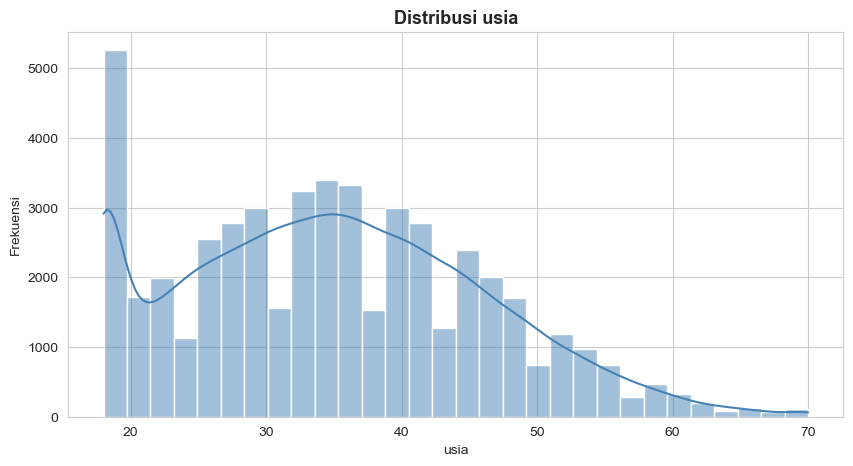

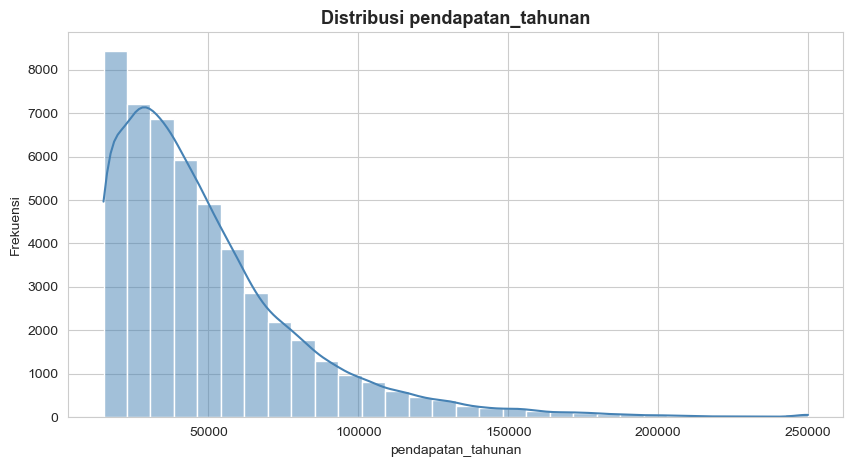

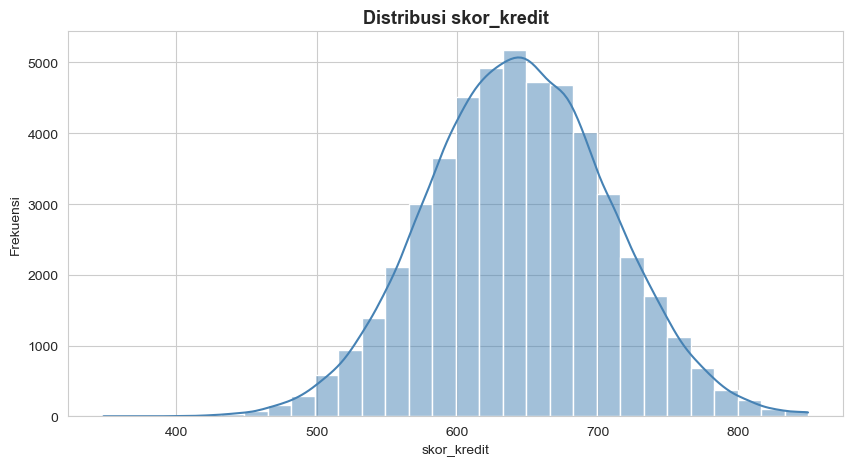

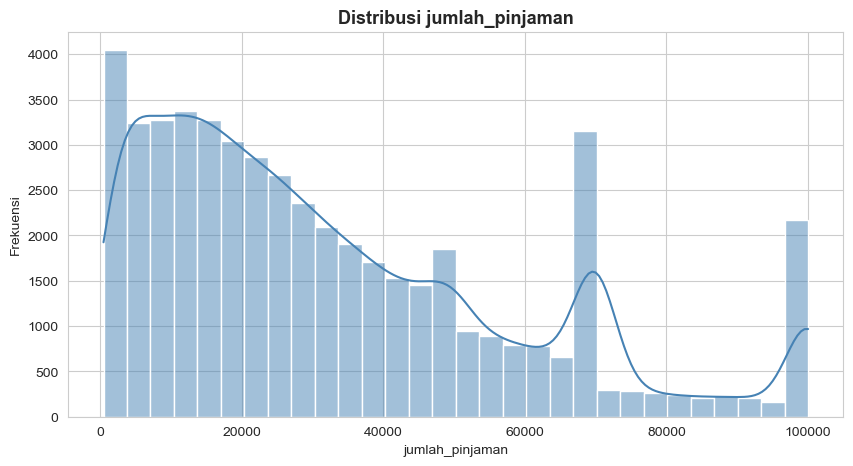

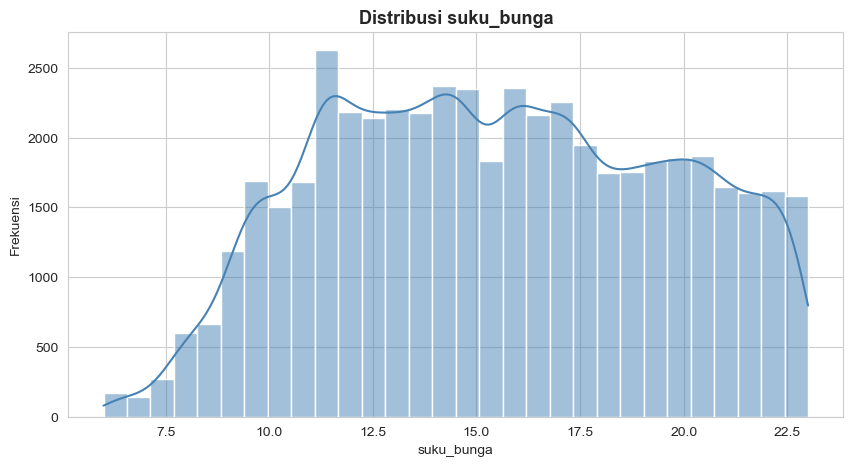

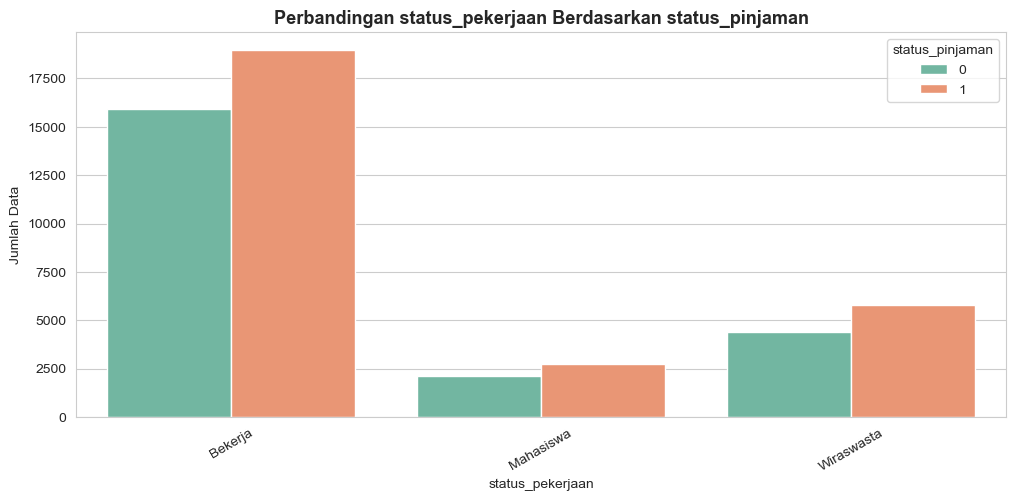

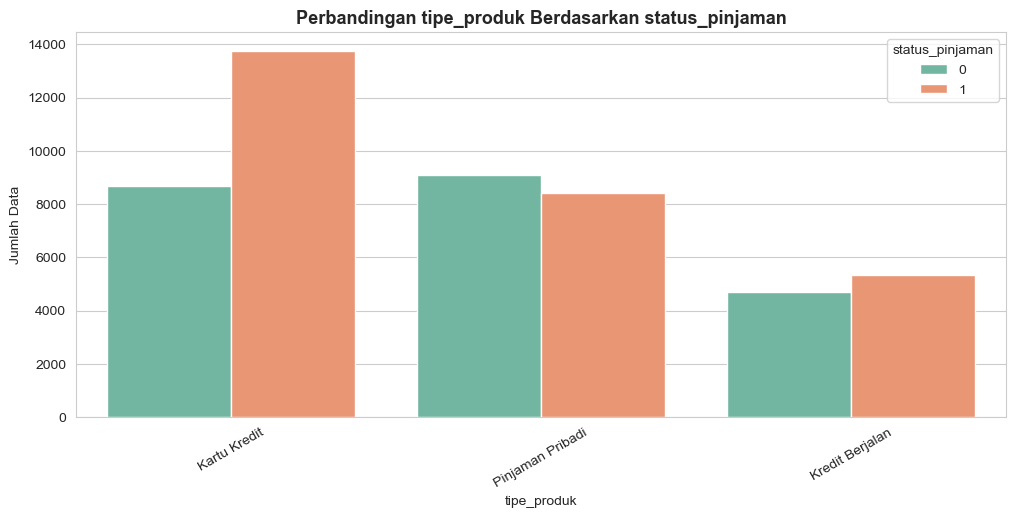

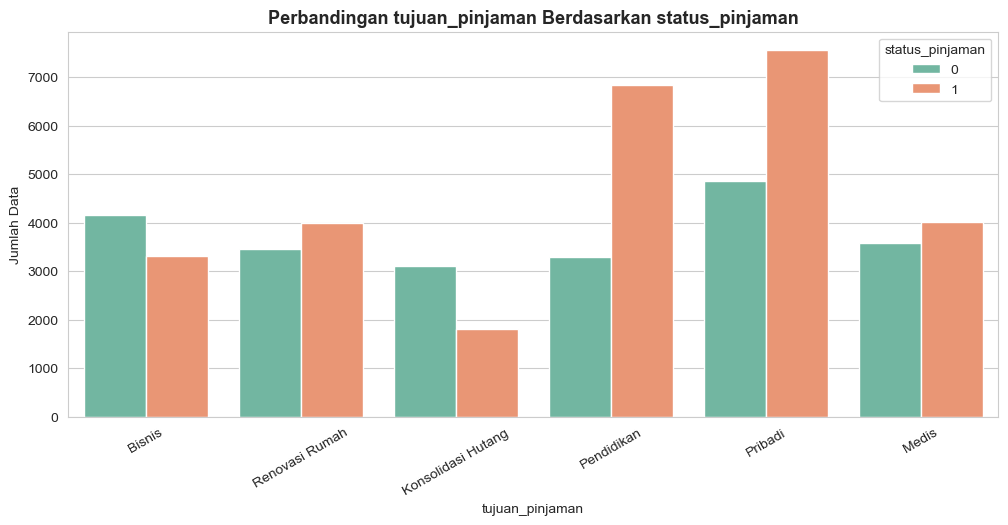

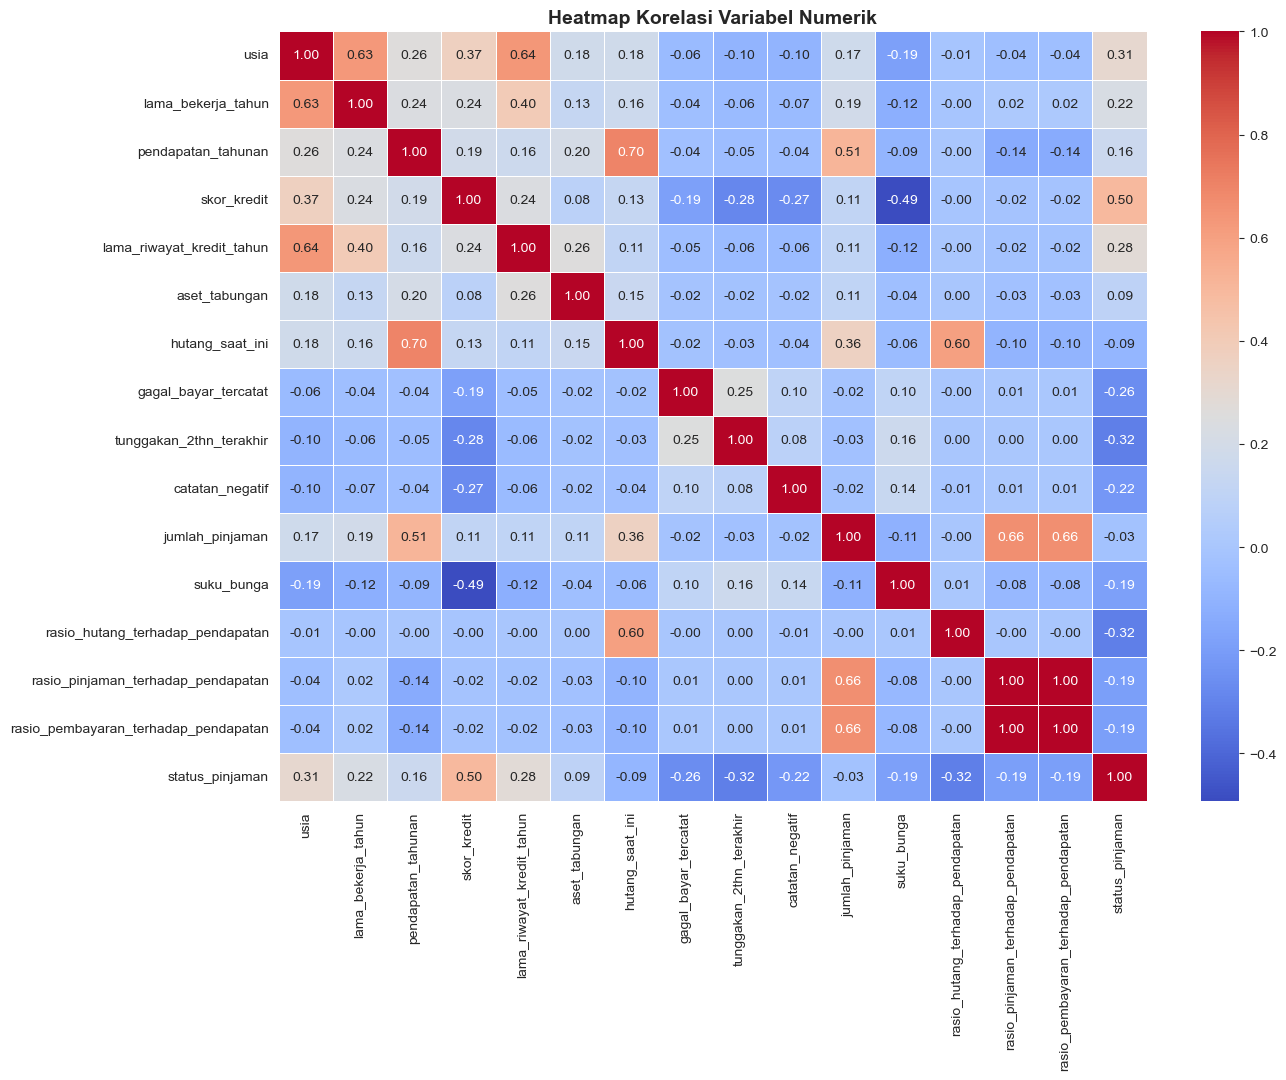

In [5]:

# ==============================================================
# VISUALISASI AWAL DATASET
# ==============================================================

print('=' * 70)
print('  VISUALISASI AWAL DATASET')
print('=' * 70)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print('Kolom Numerik:')
print(numeric_cols)

print('\nKolom Kategorikal:')
print(categorical_cols)

# Histogram beberapa kolom numerik penting
kolom_hist = ['usia', 'pendapatan_tahunan', 'skor_kredit', 'jumlah_pinjaman', 'suku_bunga']
kolom_hist = [col for col in kolom_hist if col in df.columns]

for col in kolom_hist:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=30, color='steelblue')
    plt.title(f'Distribusi {col}', fontsize=13, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

# Visualisasi kategori terhadap target
kolom_kategori_plot = ['status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman']
kolom_kategori_plot = [col for col in kolom_kategori_plot if col in df.columns]

for col in kolom_kategori_plot:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df, x=col, hue=target_col, palette='Set2')
    plt.title(f'Perbandingan {col} Berdasarkan {target_col}', fontsize=13, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Jumlah Data')
    plt.xticks(rotation=30)
    plt.legend(title=target_col)
    plt.show()

# Korelasi antar variabel numerik
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Numerik', fontsize=14, fontweight='bold')
plt.show()



<h3>FASE 3 — Data Preparation</h3>

Tahap ini bertujuan menyiapkan data agar dapat digunakan oleh algoritma machine learning. Proses yang dilakukan meliputi data cleaning, pengecekan missing values, penghapusan duplikat, handling missing values, deteksi outlier, pemilihan fitur, encoding data kategorikal, normalisasi untuk algoritma tertentu, serta pembagian data training dan testing.


# Penjelasan Cell

## Data Cleaning

### Tujuan
Membersihkan dataset agar kualitas data lebih baik dan siap digunakan dalam proses pemodelan machine learning.

### Penjelasan Kode
- `df_clean = df.copy()` : membuat salinan dataset asli agar data sumber tetap aman.
- `duplicated().sum()` : menghitung jumlah data duplikat pada dataset.
- `drop_duplicates()` : menghapus data yang terduplikasi.
- `str.strip()` : menghapus spasi berlebih pada data kategorikal.
- `replace(['nan','None',''], np.nan)` : menyamakan format data kosong menjadi `NaN`.
- `dropna(subset=[target_col])` : menghapus data yang tidak memiliki nilai target.
- `fillna(median)` : mengisi missing value pada data numerik menggunakan nilai median.
- `fillna(mode)` : mengisi missing value pada data kategorikal menggunakan nilai yang paling sering muncul.

### Kesimpulan
Cell ini digunakan untuk membersihkan dan memperbaiki kualitas dataset sehingga data menjadi lebih konsisten, lengkap, dan siap digunakan pada tahap analisis serta pemodelan.

In [6]:

# ==============================================================
# FASE 3 - DATA CLEANING
# ==============================================================

print('=' * 70)
print('  FASE 3: DATA PREPARATION - DATA CLEANING')
print('=' * 70)

df_clean = df.copy()

print('Jumlah data sebelum cleaning:', df_clean.shape)

# 1. Hapus data duplikat
jumlah_duplikat = df_clean.duplicated().sum()
print(f'Jumlah data duplikat: {jumlah_duplikat}')

df_clean = df_clean.drop_duplicates()
print('Jumlah data setelah hapus duplikat:', df_clean.shape)

# 2. Membersihkan spasi pada kolom kategorikal
object_cols = df_clean.select_dtypes(include='object').columns.tolist()

for col in object_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = df_clean[col].replace(['nan', 'None', ''], np.nan)

print('\nMissing values sebelum handling:')
display(df_clean.isnull().sum().to_frame('Jumlah Missing'))

# 3. Handling missing values
num_cols_clean = df_clean.select_dtypes(include=np.number).columns.tolist()
cat_cols_clean = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Jika target ada missing, baris target kosong dihapus
df_clean = df_clean.dropna(subset=[target_col])

# Missing numerik diisi median
for col in num_cols_clean:
    if col != target_col and df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)
        print(f'Missing numerik kolom {col} diisi dengan median: {median_value}')

# Missing kategorikal diisi modus
for col in cat_cols_clean:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_value)
        print(f'Missing kategorikal kolom {col} diisi dengan modus: {mode_value}')

print('\nMissing values setelah handling:')
display(df_clean.isnull().sum().to_frame('Jumlah Missing'))

print('\nJumlah data setelah cleaning:', df_clean.shape)
display(df_clean.head())


  FASE 3: DATA PREPARATION - DATA CLEANING
Jumlah data sebelum cleaning: (50000, 20)
Jumlah data duplikat: 0
Jumlah data setelah hapus duplikat: (50000, 20)

Missing values sebelum handling:


,Jumlah Missing
id_pelanggan,0
usia,147
status_pekerjaan,153
lama_bekerja_tahun,0
pendapatan_tahunan,0
skor_kredit,0
lama_riwayat_kredit_tahun,0
aset_tabungan,0
hutang_saat_ini,0
gagal_bayar_tercatat,0


Missing numerik kolom usia diisi dengan median: 35.0
Missing kategorikal kolom status_pekerjaan diisi dengan modus: Bekerja

Missing values setelah handling:


,Jumlah Missing
id_pelanggan,0
usia,0
status_pekerjaan,0
lama_bekerja_tahun,0
pendapatan_tahunan,0
skor_kredit,0
lama_riwayat_kredit_tahun,0
aset_tabungan,0
hutang_saat_ini,0
gagal_bayar_tercatat,0



Jumlah data setelah cleaning: (50000, 20)


,id_pelanggan,usia,status_pekerjaan,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,tipe_produk,tujuan_pinjaman,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
0,CUST100000,40.0,Bekerja,17.2,25579,692,5.3,895,10820,0,0,0,Kartu Kredit,Bisnis,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33.0,Bekerja,7.3,43087,627,3.5,169,16550,0,1,0,Pinjaman Pribadi,Renovasi Rumah,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42.0,Mahasiswa,1.1,20840,689,8.4,17,7852,0,0,0,Kartu Kredit,Konsolidasi Hutang,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53.0,Mahasiswa,0.5,29147,692,9.8,1480,11603,0,1,0,Kartu Kredit,Bisnis,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32.0,Bekerja,12.5,63657,630,7.2,209,12424,0,0,0,Pinjaman Pribadi,Pendidikan,99600,13.92,0.195,1.565,0.522,1


# Penjelasan Cell

## Deteksi Outlier

### Tujuan
Mendeteksi data ekstrem (outlier) pada dataset menggunakan metode Interquartile Range (IQR) untuk mengetahui apakah terdapat nilai yang jauh berbeda dari mayoritas data.

### Penjelasan Kode
- `Q1` : menghitung kuartil pertama (25% data terendah).
- `Q3` : menghitung kuartil ketiga (75% data tertinggi).
- `IQR = Q3 - Q1` : menghitung rentang data normal menggunakan metode Interquartile Range.
- `lower_bound` : menentukan batas bawah data normal.
- `upper_bound` : menentukan batas atas data normal.
- Data yang berada di luar batas tersebut dianggap sebagai outlier.
- `boxplot` : memvisualisasikan sebaran data dan menunjukkan keberadaan outlier secara grafik.

### Kesimpulan
Cell ini digunakan untuk mengidentifikasi data ekstrem yang berpotensi memengaruhi hasil analisis dan performa model klasifikasi sehingga dapat dipertimbangkan pada tahap preprocessing selanjutnya.

  DETEKSI OUTLIER MENGGUNAKAN METODE IQR


,Kolom,Lower Bound,Upper Bound,Jumlah Outlier,Persentase (%)
5,aset_tabungan,-3081.500000,5482.500000,6508,13.02
9,catatan_negatif,0.000000,0.000000,6393,12.79
6,hutang_saat_ini,-13721.375000,37751.625000,2932,5.86
7,gagal_bayar_tercatat,0.000000,0.000000,2674,5.35
2,pendapatan_tahunan,-25883.625000,115887.375000,2355,4.71
8,tunggakan_2thn_terakhir,-1.500000,2.500000,1761,3.52
1,lama_bekerja_tahun,-13.850000,26.550000,1373,2.75
3,skor_kredit,469.500000,817.500000,349,0.70
4,lama_riwayat_kredit_tahun,-13.900000,28.500000,349,0.70
12,rasio_hutang_terhadap_pendapatan,-0.181000,0.731000,332,0.66


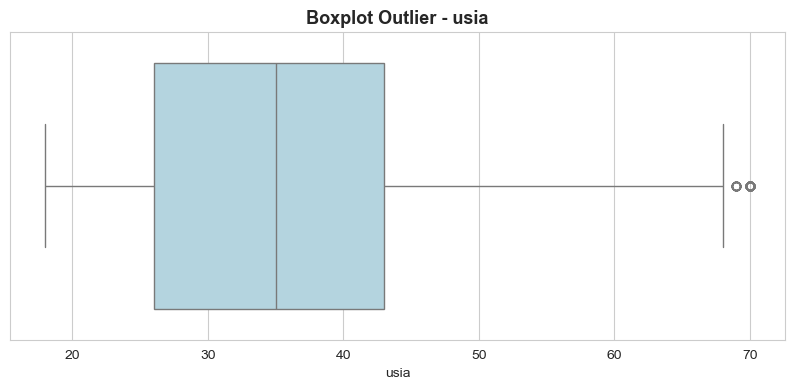

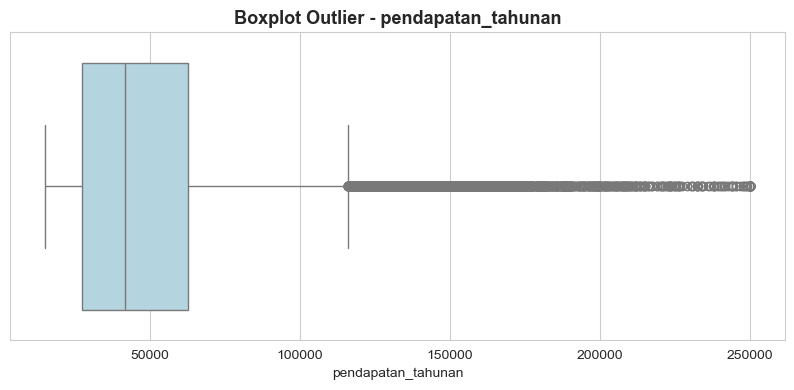

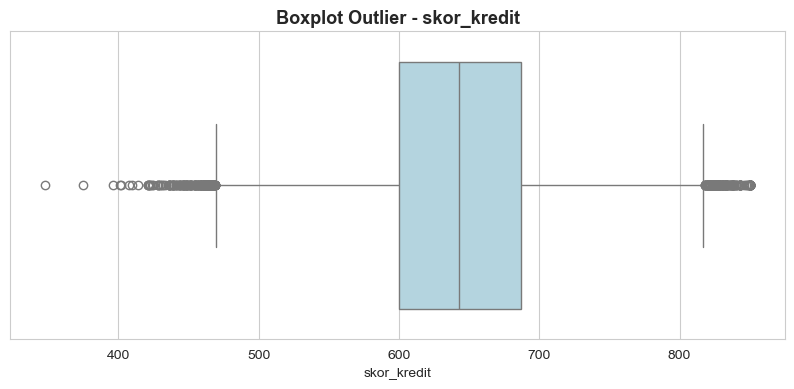

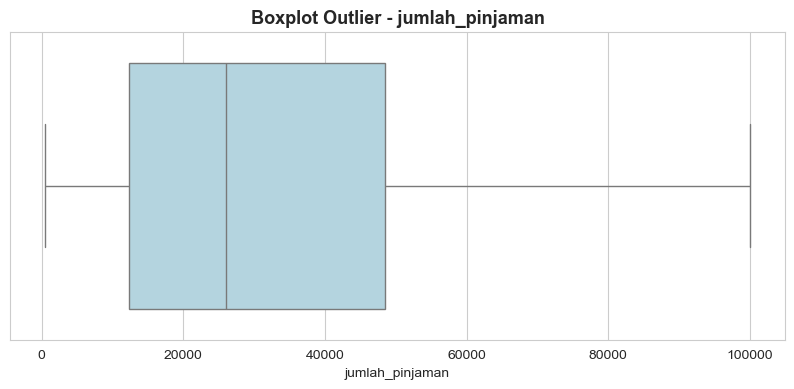

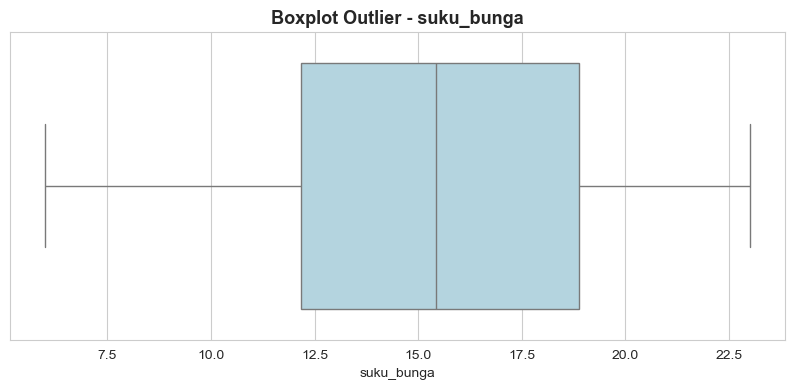

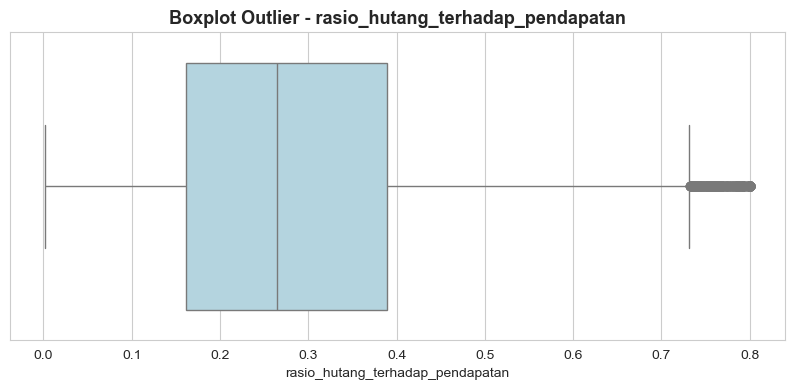

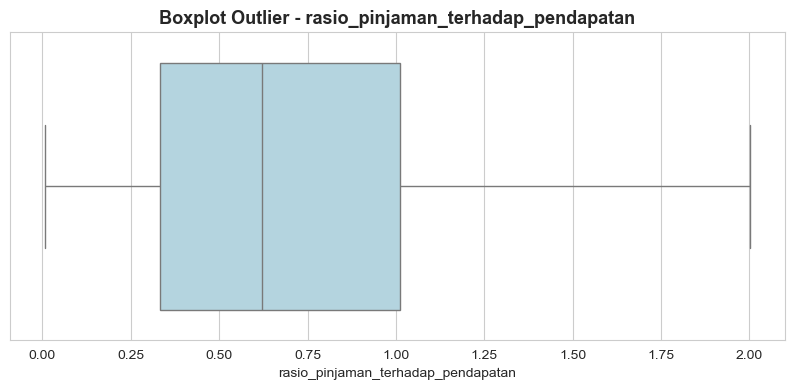

Catatan:
Outlier pada data keuangan tidak langsung dihapus karena dapat merepresentasikan kondisi pelanggan yang valid.
Algoritma utama Random Forest relatif robust terhadap outlier, sehingga data outlier tetap dipertahankan.


In [7]:

# ==============================================================
# DETEKSI OUTLIER
# ==============================================================

print('=' * 70)
print('  DETEKSI OUTLIER MENGGUNAKAN METODE IQR')
print('=' * 70)

# Kolom numerik untuk deteksi outlier, target tidak dihitung sebagai outlier
numeric_features_for_outlier = [
    col for col in df_clean.select_dtypes(include=np.number).columns
    if col != target_col
]

outlier_summary = []

for col in numeric_features_for_outlier:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    jumlah_outlier = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    persentase = (jumlah_outlier / len(df_clean)) * 100

    outlier_summary.append({
        'Kolom': col,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Jumlah Outlier': jumlah_outlier,
        'Persentase (%)': round(persentase, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Jumlah Outlier', ascending=False)
display(outlier_df)

# Visualisasi boxplot untuk beberapa kolom numerik penting
kolom_boxplot = ['usia', 'pendapatan_tahunan', 'skor_kredit', 'jumlah_pinjaman', 'suku_bunga',
                 'rasio_hutang_terhadap_pendapatan', 'rasio_pinjaman_terhadap_pendapatan']
kolom_boxplot = [col for col in kolom_boxplot if col in df_clean.columns]

for col in kolom_boxplot:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df_clean[col], color='lightblue')
    plt.title(f'Boxplot Outlier - {col}', fontsize=13, fontweight='bold')
    plt.xlabel(col)
    plt.show()

print('Catatan:')
print('Outlier pada data keuangan tidak langsung dihapus karena dapat merepresentasikan kondisi pelanggan yang valid.')
print('Algoritma utama Random Forest relatif robust terhadap outlier, sehingga data outlier tetap dipertahankan.')


# Penjelasan Cell

## Persiapan Fitur, Encoding, Normalisasi, dan Split Data

### Tujuan
Menyiapkan data sebelum proses pemodelan dengan menentukan fitur dan target, melakukan preprocessing, serta membagi data menjadi data training dan testing.

### Penjelasan Kode
- `id_cols` : mengidentifikasi kolom ID yang hanya berfungsi sebagai identitas sehingga tidak digunakan sebagai fitur model.
- `X = df_clean.drop(...)` : membuat variabel fitur (predictor) dengan menghapus kolom target dan ID.
- `y = df_clean[target_col]` : menentukan variabel target yang akan diprediksi.
- `numeric_features` : mengambil seluruh fitur numerik.
- `categorical_features` : mengambil seluruh fitur kategorikal.
- `buat_onehot_encoder()` : mengubah data kategorikal menjadi data numerik menggunakan One Hot Encoding.
- `SimpleImputer(strategy='median')` : mengisi missing value pada data numerik menggunakan median.
- `SimpleImputer(strategy='most_frequent')` : mengisi missing value pada data kategorikal menggunakan nilai yang paling sering muncul.
- `StandardScaler()` : melakukan normalisasi data numerik agar memiliki skala yang sama.
- `ColumnTransformer()` : menggabungkan proses preprocessing untuk fitur numerik dan kategorikal.
- `Pipeline()` : mengotomatisasi tahapan preprocessing sebelum data masuk ke model.
- `train_test_split()` : membagi dataset menjadi data training (80%) dan data testing (20%).
- `stratify=y` : menjaga proporsi kelas target tetap seimbang pada data training dan testing.

### Kesimpulan
Cell ini digunakan untuk menyiapkan data agar siap digunakan dalam proses machine learning melalui encoding, penanganan missing value, normalisasi data, serta pembagian dataset menjadi data training dan testing.

In [8]:

# ==============================================================
# PERSIAPAN FITUR, ENCODING, NORMALISASI, DAN SPLIT DATA
# ==============================================================

print('=' * 70)
print('  PERSIAPAN FITUR DAN TARGET')
print('=' * 70)

# Kolom id_pelanggan adalah identifier, sehingga tidak digunakan sebagai fitur model
id_cols = [col for col in df_clean.columns if col.lower().startswith('id') or 'id_' in col.lower()]

print('Kolom identifier yang dihapus dari fitur:')
print(id_cols)

X = df_clean.drop(columns=[target_col] + id_cols)
y = df_clean[target_col]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print('\nJumlah fitur:', X.shape[1])
print('Fitur numerik:', numeric_features)
print('Fitur kategorikal:', categorical_features)

# Fungsi kompatibilitas OneHotEncoder untuk beberapa versi scikit-learn
def buat_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

# Preprocessing untuk model berbasis tree
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', buat_onehot_encoder())
        ]), categorical_features)
    ]
)

# Preprocessing untuk model yang membutuhkan scaling
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', buat_onehot_encoder())
        ]), categorical_features)
    ]
)

# Split data training dan testing 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('\nPembagian Data:')
print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test : {y_test.shape}')

print('\nDistribusi target pada data training:')
display(y_train.value_counts(normalize=True).sort_index().to_frame('Proporsi Training'))

print('\nDistribusi target pada data testing:')
display(y_test.value_counts(normalize=True).sort_index().to_frame('Proporsi Testing'))


  PERSIAPAN FITUR DAN TARGET
Kolom identifier yang dihapus dari fitur:
['id_pelanggan']

Jumlah fitur: 18
Fitur numerik: ['usia', 'lama_bekerja_tahun', 'pendapatan_tahunan', 'skor_kredit', 'lama_riwayat_kredit_tahun', 'aset_tabungan', 'hutang_saat_ini', 'gagal_bayar_tercatat', 'tunggakan_2thn_terakhir', 'catatan_negatif', 'jumlah_pinjaman', 'suku_bunga', 'rasio_hutang_terhadap_pendapatan', 'rasio_pinjaman_terhadap_pendapatan', 'rasio_pembayaran_terhadap_pendapatan']
Fitur kategorikal: ['status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman']

Pembagian Data:
X_train: (40000, 18)
X_test : (10000, 18)
y_train: (40000,)
y_test : (10000,)

Distribusi target pada data training:


,Proporsi Training
status_pinjaman,
0,0.44955
1,0.55045



Distribusi target pada data testing:


,Proporsi Testing
status_pinjaman,
0,0.4495
1,0.5505



<h3>FASE 4 — Modeling</h3>

Pada tahap modeling, beberapa algoritma klasifikasi dibandingkan untuk mencari model terbaik. Algoritma yang digunakan adalah:

1. <b>Decision Tree</b> — mudah dipahami dan cocok untuk klasifikasi.  
2. <b>Random Forest</b> — kumpulan banyak decision tree sehingga biasanya lebih stabil dan akurat.  
3. <b>Logistic Regression</b> — cocok untuk klasifikasi biner dan menjadi baseline yang baik.  
4. <b>K-Nearest Neighbor</b> — melakukan klasifikasi berdasarkan kemiripan data terdekat.  

Model utama yang direkomendasikan adalah <b>Random Forest</b> karena cocok untuk data campuran numerik dan kategorikal, robust terhadap outlier, serta mampu menangkap hubungan non-linear antar fitur.


# Penjelasan Cell

## Modeling

### Tujuan
Membangun dan membandingkan beberapa algoritma klasifikasi untuk menentukan model terbaik dalam memprediksi status pinjaman pelanggan.

### Penjelasan Kode
- `models = {...}` : menyimpan beberapa algoritma klasifikasi yang akan dibandingkan.
- `DecisionTreeClassifier()` : membangun model berbasis pohon keputusan dengan parameter untuk mengurangi overfitting.
- `RandomForestClassifier()` : membangun model ensemble yang terdiri dari banyak pohon keputusan untuk meningkatkan akurasi prediksi.
- `LogisticRegression()` : membangun model klasifikasi biner untuk memprediksi status pinjaman.
- `KNeighborsClassifier()` : membangun model berdasarkan kemiripan data dengan tetangga terdekat.
- `Pipeline()` : menggabungkan preprocessing dan model menjadi satu proses yang terintegrasi.
- `pipeline_model.fit(X_train, y_train)` : melatih model menggunakan data training.
- `pipeline_model.predict(X_test)` : melakukan prediksi pada data testing.
- `accuracy_score()` : menghitung tingkat akurasi model.
- `precision_score()` : menghitung ketepatan prediksi model.
- `recall_score()` : menghitung kemampuan model dalam menemukan kelas yang benar.
- `f1_score()` : menghitung keseimbangan antara precision dan recall.
- `pd.DataFrame(hasil_model)` : menyimpan hasil evaluasi seluruh model dalam bentuk tabel.
- `sort_values(by='Accuracy')` : mengurutkan model berdasarkan nilai accuracy tertinggi.
- `best_model_name` : menentukan model terbaik berdasarkan hasil accuracy tertinggi.

### Kesimpulan
Cell ini digunakan untuk melatih, menguji, dan membandingkan beberapa algoritma klasifikasi sehingga dapat diperoleh model terbaik yang akan digunakan untuk memprediksi status pinjaman pelanggan.

In [9]:

# ==============================================================
# FASE 4 - MODELING
# ==============================================================

print('=' * 70)
print('  FASE 4: MODELING - PERBANDINGAN MODEL KLASIFIKASI')
print('=' * 70)

models = {
    'Decision Tree': Pipeline(steps=[
        ('preprocess', preprocessor_tree),
        ('model', DecisionTreeClassifier(
            random_state=42,
            max_depth=8,
            min_samples_leaf=20
        ))
    ]),

    'Random Forest': Pipeline(steps=[
        ('preprocess', preprocessor_tree),
        ('model', RandomForestClassifier(
            n_estimators=120,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
        ))
    ]),

    'Logistic Regression': Pipeline(steps=[
        ('preprocess', preprocessor_scaled),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight='balanced'
        ))
    ]),

    'K-Nearest Neighbor': Pipeline(steps=[
        ('preprocess', preprocessor_scaled),
        ('model', KNeighborsClassifier(
            n_neighbors=7
        ))
    ])
}

hasil_model = []

for nama_model, pipeline_model in models.items():
    print(f'\nTraining model: {nama_model}')

    pipeline_model.fit(X_train, y_train)
    y_pred = pipeline_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    hasil_model.append({
        'Model': nama_model,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(f'Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-Score : {f1:.4f}')

hasil_model_df = pd.DataFrame(hasil_model).sort_values(by='Accuracy', ascending=False)

print('\nRingkasan Perbandingan Model:')
display(hasil_model_df)

best_model_name = hasil_model_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f'\nModel terbaik berdasarkan Accuracy: {best_model_name}')


  FASE 4: MODELING - PERBANDINGAN MODEL KLASIFIKASI

Training model: Decision Tree
Accuracy : 0.8733 (87.33%)
Precision: 0.8743
Recall   : 0.8733
F1-Score : 0.8727

Training model: Random Forest
Accuracy : 0.9123 (91.23%)
Precision: 0.9123
Recall   : 0.9123
F1-Score : 0.9122

Training model: Logistic Regression
Accuracy : 0.8627 (86.27%)
Precision: 0.8631
Recall   : 0.8627
F1-Score : 0.8628

Training model: K-Nearest Neighbor
Accuracy : 0.8707 (87.07%)
Precision: 0.8720
Recall   : 0.8707
F1-Score : 0.8700

Ringkasan Perbandingan Model:


,Model,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.9123,0.912253,0.9123,0.912242
0,Decision Tree,0.8733,0.874303,0.8733,0.872674
3,K-Nearest Neighbor,0.8707,0.872006,0.8707,0.869973
2,Logistic Regression,0.8627,0.863086,0.8627,0.862818



Model terbaik berdasarkan Accuracy: Random Forest


Accuracy : 0.8627 (86.27%)
Precision: 0.8631
Recall   : 0.8627
F1-Score : 0.8628

Training model: K-Nearest Neighbor


Accuracy : 0.8707 (87.07%)
Precision: 0.8720
Recall   : 0.8707
F1-Score : 0.8700

Ringkasan Perbandingan Model:


,Model,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.9123,0.912253,0.9123,0.912242
0,Decision Tree,0.8733,0.874303,0.8733,0.872674
3,K-Nearest Neighbor,0.8707,0.872006,0.8707,0.869973
2,Logistic Regression,0.8627,0.863086,0.8627,0.862818



Model terbaik berdasarkan Accuracy: Random Forest



<h3>FASE 5 — Evaluation</h3>

Evaluasi dilakukan untuk mengetahui seberapa baik model dalam memprediksi <code>status_pinjaman</code>. Metrik evaluasi yang digunakan yaitu accuracy, precision, recall, F1-score, classification report, confusion matrix, dan cross validation.


# Penjelasan Cell

## Evaluation Model Terbaik

### Tujuan
Mengevaluasi performa model terbaik yang diperoleh dari tahap modeling untuk mengetahui tingkat akurasi dan kualitas prediksi dalam klasifikasi status pinjaman.

### Penjelasan Kode
- `best_model.predict(X_test)` : melakukan prediksi status pinjaman menggunakan model terbaik pada data testing.
- `accuracy_score()` : menghitung persentase prediksi yang benar dari seluruh data testing.
- `precision_score()` : mengukur ketepatan model dalam memberikan prediksi pada setiap kelas.
- `recall_score()` : mengukur kemampuan model dalam menemukan seluruh data yang benar pada setiap kelas.
- `f1_score()` : menghitung keseimbangan antara precision dan recall.
- `classification_report()` : menampilkan ringkasan metrik evaluasi seperti precision, recall, f1-score, dan support untuk setiap kelas.
- `cross_val_score()` : melakukan validasi silang (5-Fold Cross Validation) untuk mengukur kestabilan model pada beberapa pembagian data yang berbeda.
- `cv_scores.mean()` : menghitung rata-rata nilai akurasi hasil cross validation.
- `cv_scores.std()` : menghitung standar deviasi untuk melihat konsistensi performa model.
- `Accuracy >= 80%` : digunakan untuk mengecek apakah model telah memenuhi kriteria keberhasilan yang ditentukan.

### Kesimpulan
Cell ini digunakan untuk mengukur dan memvalidasi performa model terbaik menggunakan berbagai metrik evaluasi sehingga dapat diketahui tingkat akurasi, kestabilan model, dan keberhasilan model dalam memprediksi status pinjaman pelanggan.

In [10]:

# ==============================================================
# FASE 5 - EVALUATION MODEL TERBAIK
# ==============================================================

print('=' * 70)
print('  FASE 5: EVALUATION - MODEL TERBAIK')
print('=' * 70)

# Prediksi menggunakan model terbaik
y_pred_best = best_model.predict(X_test)

acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best, average='weighted', zero_division=0)
rec_best = recall_score(y_test, y_pred_best, average='weighted', zero_division=0)
f1_best = f1_score(y_test, y_pred_best, average='weighted', zero_division=0)

print(f'Model Terbaik: {best_model_name}')
print(f'Accuracy     : {acc_best:.4f} ({acc_best*100:.2f}%)')
print(f'Precision    : {prec_best:.4f}')
print(f'Recall       : {rec_best:.4f}')
print(f'F1-Score     : {f1_best:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_best, zero_division=0))

# Cross Validation
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')
print('\nCross Validation 5-Fold:')
print(f'Skor setiap fold : {cv_scores}')
print(f'Rata-rata CV     : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)')
print(f'Standar deviasi  : {cv_scores.std():.4f}')

print('\nKriteria Sukses:')
print(f'Accuracy >= 80% : {"TERCAPAI" if acc_best >= 0.80 else "BELUM TERCAPAI"}')


  FASE 5: EVALUATION - MODEL TERBAIK
Model Terbaik: Random Forest
Accuracy     : 0.9123 (91.23%)
Precision    : 0.9123
Recall       : 0.9123
F1-Score     : 0.9122

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      4495
           1       0.92      0.93      0.92      5505

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000


Cross Validation 5-Fold:
Skor setiap fold : [0.9081 0.9173 0.9167 0.9135 0.9138]
Rata-rata CV     : 0.9139 (91.39%)
Standar deviasi  : 0.0033

Kriteria Sukses:
Accuracy >= 80% : TERCAPAI



Cross Validation 5-Fold:
Skor setiap fold : [0.9081 0.9173 0.9167 0.9135 0.9138]
Rata-rata CV     : 0.9139 (91.39%)
Standar deviasi  : 0.0033

Kriteria Sukses:
Accuracy >= 80% : TERCAPAI


# Penjelasan Cell

## Visualisasi Hasil Evaluasi

### Tujuan
Menampilkan hasil evaluasi model secara visual agar performa model lebih mudah dipahami dan dianalisis.

### Penjelasan Kode
- `confusion_matrix()` : membuat Confusion Matrix untuk membandingkan hasil prediksi dengan data aktual.
- `sns.heatmap()` : memvisualisasikan Confusion Matrix dalam bentuk heatmap sehingga kesalahan dan keberhasilan prediksi dapat terlihat dengan jelas.
- `hasil_model_df.melt()` : mengubah format data hasil evaluasi agar dapat digunakan untuk visualisasi perbandingan model.
- `sns.barplot()` : menampilkan grafik perbandingan nilai Accuracy, Precision, Recall, dan F1-Score dari seluruh model klasifikasi.
- `best_model.named_steps['model']` : mengambil model terbaik dari pipeline.
- `feature_importances_` : menghitung tingkat pengaruh setiap fitur terhadap hasil prediksi (khusus untuk model berbasis tree seperti Decision Tree dan Random Forest).
- `importance_df` : menyimpan nilai importance setiap fitur dalam bentuk tabel.
- `sns.barplot(data=importance_df.head(15))` : menampilkan 15 fitur yang paling berpengaruh terhadap prediksi status pinjaman.

### Kesimpulan
Cell ini digunakan untuk memvisualisasikan hasil evaluasi model melalui Confusion Matrix, perbandingan performa antar model, dan Feature Importance sehingga dapat diketahui tingkat akurasi model serta faktor-faktor yang paling memengaruhi status pinjaman pelanggan.

  VISUALISASI HASIL EVALUASI


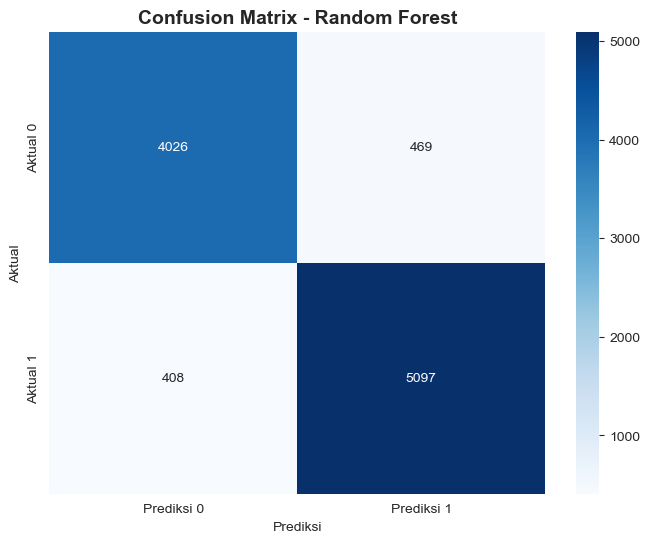

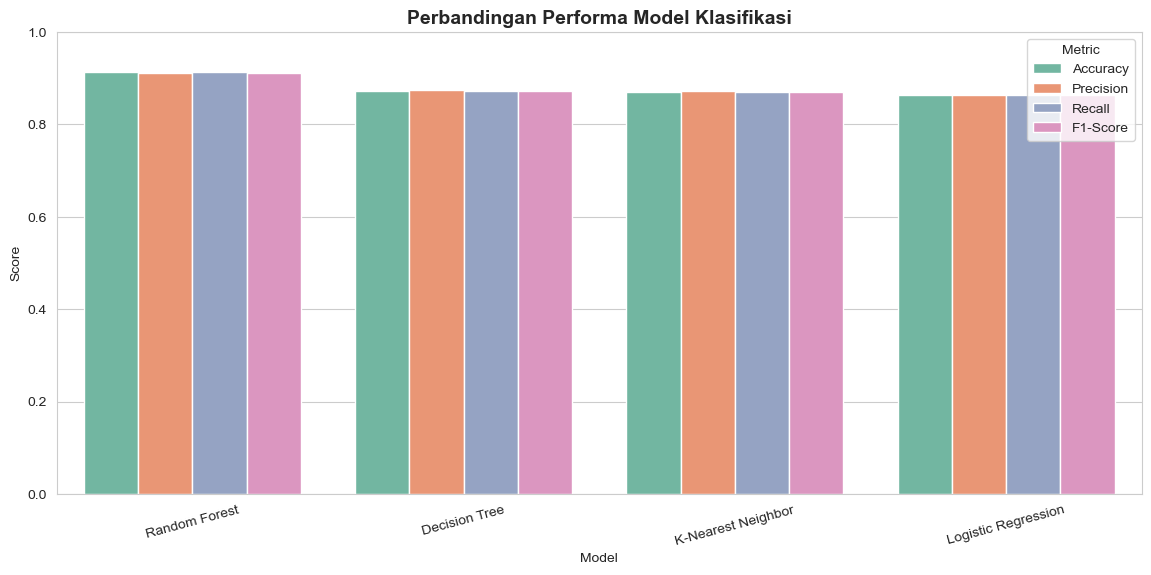


Top 15 Feature Importance:


,Fitur,Importance
3,skor_kredit,0.211949
12,rasio_hutang_terhadap_pendapatan,0.167680
11,suku_bunga,0.067491
4,lama_riwayat_kredit_tahun,0.065435
8,tunggakan_2thn_terakhir,0.055000
13,rasio_pinjaman_terhadap_pendapatan,0.045366
0,usia,0.042155
14,rasio_pembayaran_terhadap_pendapatan,0.041549
6,hutang_saat_ini,0.037706
1,lama_bekerja_tahun,0.037686


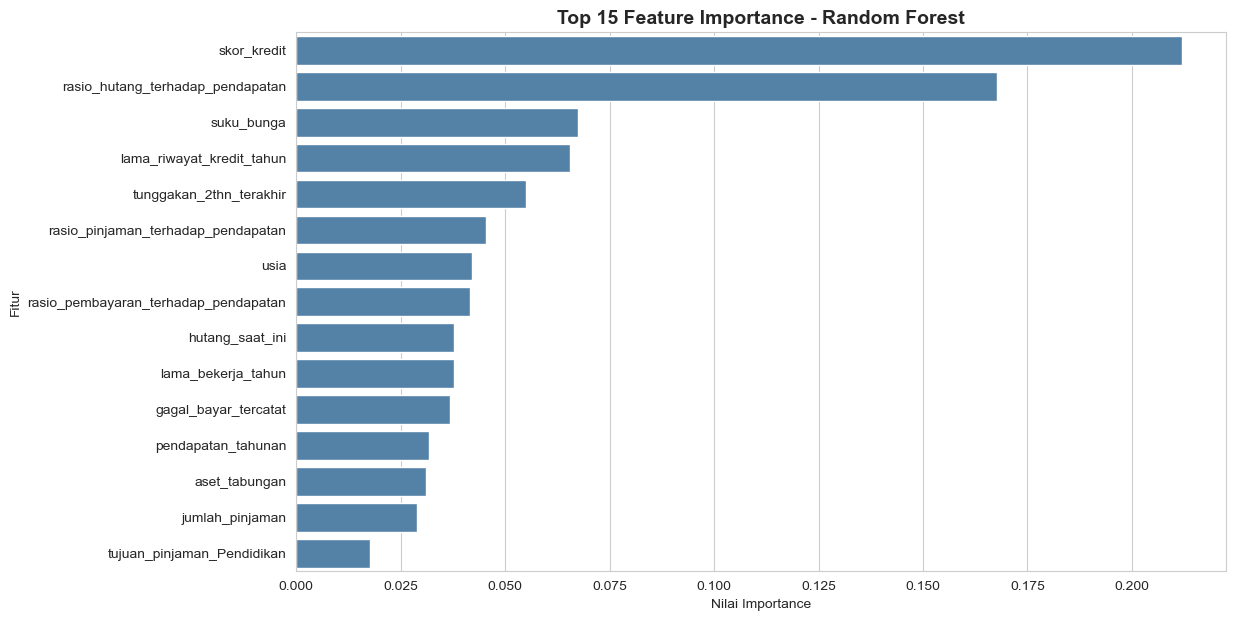

In [11]:

# ==============================================================
# VISUALISASI HASIL EVALUASI
# ==============================================================

print('=' * 70)
print('  VISUALISASI HASIL EVALUASI')
print('=' * 70)

# Confusion Matrix
class_order = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_best, labels=class_order)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'Prediksi {c}' for c in class_order],
    yticklabels=[f'Aktual {c}' for c in class_order]
)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# Visualisasi perbandingan model
hasil_melt = hasil_model_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.barplot(data=hasil_melt, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title('Perbandingan Performa Model Klasifikasi', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.ylabel('Score')
plt.show()

# Feature Importance untuk Random Forest / Decision Tree
model_utama = best_model.named_steps['model']

if hasattr(model_utama, 'feature_importances_'):
    feature_names = best_model.named_steps['preprocess'].get_feature_names_out()
    feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

    importance_df = pd.DataFrame({
        'Fitur': feature_names,
        'Importance': model_utama.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    print('\nTop 15 Feature Importance:')
    display(importance_df.head(15))

    plt.figure(figsize=(12, 7))
    sns.barplot(data=importance_df.head(15), x='Importance', y='Fitur', color='steelblue')
    plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Nilai Importance')
    plt.ylabel('Fitur')
    plt.show()
else:
    print('Model terbaik tidak memiliki atribut feature_importances_.')


# Penjelasan Cell

## Ringkasan Akhir Project

### Tujuan
Menampilkan ringkasan hasil akhir project klasifikasi status pinjaman berdasarkan model terbaik yang telah dievaluasi.

### Penjelasan Kode
- `print()` : menampilkan informasi hasil project ke layar.
- `df.shape[0]` : menampilkan jumlah baris (data) pada dataset.
- `df.shape[1]` : menampilkan jumlah kolom (atribut) pada dataset.
- `target_col` : menampilkan nama variabel target yang diprediksi.
- `best_model_name` : menampilkan model dengan performa terbaik.
- `acc_best` : menampilkan nilai accuracy model terbaik.
- `prec_best` : menampilkan nilai precision model terbaik.
- `rec_best` : menampilkan nilai recall model terbaik.
- `f1_best` : menampilkan nilai F1-Score model terbaik.
- `if acc_best >= 0.80` : memeriksa apakah model telah memenuhi kriteria keberhasilan minimal 80% accuracy.
- `print('Kesimpulan')` : menampilkan kesimpulan akhir berdasarkan hasil evaluasi model.

### Kesimpulan
Cell ini digunakan untuk merangkum seluruh hasil project, mulai dari informasi dataset, target klasifikasi, model terbaik, hingga metrik evaluasi sehingga diperoleh gambaran akhir mengenai performa model dalam memprediksi status pinjaman pelanggan.

In [12]:

# ==============================================================
# RINGKASAN AKHIR PROJECT
# ==============================================================

print('=' * 70)
print('  RINGKASAN AKHIR PROJECT KLASIFIKASI')
print('=' * 70)

print(f'Judul Project       : Prediksi Status Pinjaman Pelanggan')
print(f'Metode Data Mining  : Klasifikasi')
print(f'Dataset             : data.csv')
print(f'Jumlah Data         : {df.shape[0]} baris dan {df.shape[1]} kolom')
print(f'Target Klasifikasi  : {target_col}')
print(f'Model Terbaik       : {best_model_name}')
print(f'Accuracy            : {acc_best*100:.2f}%')
print(f'Precision           : {prec_best:.4f}')
print(f'Recall              : {rec_best:.4f}')
print(f'F1-Score            : {f1_best:.4f}')

if acc_best >= 0.80:
    print('\nKesimpulan Evaluasi : Model sudah memenuhi kriteria sukses minimal 80%.')
else:
    print('\nKesimpulan Evaluasi : Model belum memenuhi kriteria sukses minimal 80% dan perlu perbaikan.')

print('\nKesimpulan:')
print('Model klasifikasi berhasil dibuat untuk memprediksi status_pinjaman pelanggan.')
print('Hasil evaluasi menunjukkan model terbaik mampu memberikan performa yang baik pada data testing.')
print('Model ini dapat membantu proses analisis status pinjaman pelanggan secara lebih cepat dan berbasis data.')


  RINGKASAN AKHIR PROJECT KLASIFIKASI
Judul Project       : Prediksi Status Pinjaman Pelanggan
Metode Data Mining  : Klasifikasi
Dataset             : data.csv
Jumlah Data         : 50000 baris dan 20 kolom
Target Klasifikasi  : status_pinjaman
Model Terbaik       : Random Forest
Accuracy            : 91.23%
Precision           : 0.9123
Recall              : 0.9123
F1-Score            : 0.9122

Kesimpulan Evaluasi : Model sudah memenuhi kriteria sukses minimal 80%.

Kesimpulan:
Model klasifikasi berhasil dibuat untuk memprediksi status_pinjaman pelanggan.
Hasil evaluasi menunjukkan model terbaik mampu memberikan performa yang baik pada data testing.
Model ini dapat membantu proses analisis status pinjaman pelanggan secara lebih cepat dan berbasis data.



<h3>FASE 6 — Deployment</h3>

Hasil akhir project akan dipublikasikan dalam bentuk **Website Portofolio menggunakan Google Sites**.

<b>Konten yang disarankan untuk Google Sites:</b>

1. <b>Judul Project</b>  
   Prediksi Status Pinjaman Pelanggan Menggunakan Metode Klasifikasi

2. <b>Identitas Mahasiswa</b>  
   - Nama: [Isi Nama Mahasiswa]  
   - NIM: [Isi NIM]  
   - Kelas: SI 24 SIM  
   - Mata Kuliah: Konsep Data Warehouse & Mining  
   - Dosen: Agus Rifaldi, S.Kom

3. <b>Deskripsi Studi Kasus</b>  
   Project ini bertujuan memprediksi status pinjaman pelanggan berdasarkan data profil dan informasi finansial pelanggan.

4. <b>Dataset dan Sumber Dataset</b>  
   - Nama file: data.csv  
   - Jumlah data: 50.000 baris  
   - Jumlah kolom: 20 kolom  
   - Sumber dataset: [Isi link dataset publik dari Kaggle/UCI/Google Dataset Search/Data.gov]

5. <b>Tahapan CRISP-DM</b>  
   - Business Understanding  
   - Data Understanding  
   - Data Preparation  
   - Modeling  
   - Evaluation  
   - Deployment

6. <b>Visualisasi Hasil Analisis</b>  
   Masukkan screenshot distribusi target, heatmap korelasi, confusion matrix, perbandingan model, dan feature importance.

7. <b>Screenshot Coding</b>  
   Masukkan screenshot proses import library, load dataset, data cleaning, modeling, dan evaluation dari notebook.

8. <b>Hasil Evaluasi Model</b>  
   Masukkan nilai accuracy, precision, recall, F1-score, classification report, dan confusion matrix.

9. <b>Kesimpulan</b>  
   Jelaskan model terbaik dan apakah hasilnya sudah mencapai kriteria sukses minimal 80%.

10. <b>Link Pendukung</b>  
   - Link GitHub: [Isi link GitHub]  
   - Link YouTube: [Isi link video presentasi]



<h3>Template README.md GitHub</h3>

```markdown
# Prediksi Status Pinjaman Pelanggan Menggunakan Metode Klasifikasi

## Deskripsi Project
Project ini merupakan tugas UAS Data Mining dengan metode klasifikasi. Tujuan project adalah membangun model machine learning untuk memprediksi `status_pinjaman` pelanggan berdasarkan data profil dan informasi finansial pelanggan.

## Dataset
- Nama file: data.csv
- Jumlah data: 50.000 baris
- Jumlah kolom: 20 kolom
- Target klasifikasi: status_pinjaman
- Sumber dataset: [Isi link dataset publik]

## Metode
Metode analisis menggunakan framework CRISP-DM:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

## Algoritma yang Digunakan
- Decision Tree
- Random Forest
- Logistic Regression
- K-Nearest Neighbor

## Hasil Evaluasi
Model terbaik: [Isi model terbaik dari hasil notebook]  
Accuracy: [Isi nilai accuracy]  
Precision: [Isi nilai precision]  
Recall: [Isi nilai recall]  
F1-Score: [Isi nilai F1-score]  

## Link Project
- Google Sites: [Isi link Google Sites]
- YouTube Presentasi: [Isi link YouTube]

## Cara Menjalankan Notebook
1. Download file repository.
2. Pastikan file `data.csv` berada dalam folder yang sama dengan notebook.
3. Buka notebook menggunakan Jupyter Notebook atau Google Colab.
4. Jalankan seluruh cell dari atas sampai bawah.
```
